# L5 Data Engineer
## Module 6 Topic 1 - Webinar
## Introduction to Data Collection and Ingestion

In this workshop we are going to learn how to perform data collection in Python


## Loading the libraries

In this case we are going to use the library pandas. You can find the documentation of the library [here](https://pandas.pydata.org/). This library is one of the most important libraries to analyse data in Python (It is connected with [Numpy](http://www.numpy.org/))

In [98]:
# Import the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import requests
from io import BytesIO
from matplotlib import pyplot as plt

In [3]:
# Reading the data from a website!
url = 'https://data.london.gov.uk/download/uk-house-price-index/70ac0766-8902-4eb5-aab5-01951aaed773/UK%20House%20price%20index-v2.xls'
## there is an normally easier way but sometimes website permission stop that!
# houses = pd.read_excel(url, sheet_name='Average price', index_col=0)

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36'
}

response = requests.get(url, headers=headers)
if response.status_code == 200:
    houses = pd.read_excel(BytesIO(response.content),
                           sheet_name='Average price',
                           index_col=0,
                           engine='openpyxl')
else:
    print(f"Failed to download: {response.status_code}")

In [4]:
houses.head()

,City of London,Barking & Dagenham,Barnet,Bexley,Brent,Bromley,Camden,Croydon,Ealing,Enfield,...,NORTH WEST,YORKS & THE HUMBER,EAST MIDLANDS,WEST MIDLANDS,EAST OF ENGLAND,LONDON,SOUTH EAST,SOUTH WEST,Unnamed: 47,England
NaT,E09000001,E09000002,E09000003,E09000004,E09000005,E09000006,E09000007,E09000008,E09000009,E09000010,...,E12000002,E12000003,E12000004,E12000005,E12000006,E12000007,E12000008,E12000009,NaN,E92000001
1995-01-01,90347,51870,98948,64956,76880,83082,119775,70118,85469,77018,...,40907,42171,43856,46470,56098,79687,64502,52799,NaN,50231
1995-02-01,81213,52513,98848,64786,77651,83068,118365,69908,86551,77698,...,40877,41912,44344,47249,55991,77913,64196,52462,NaN,50130
1995-03-01,78168,52701,97848,64366,77644,82856,119131,69666,87067,76674,...,41351,42544,43701,47345,55574,79110,64597,51716,NaN,50229
1995-04-01,76172,54618,96273,64276,78668,82525,118948,69562,87933,75880,...,41195,42934,44414,47359,55966,79708,65111,52877,NaN,50597


In [7]:
houses.tail()

,City of London,Barking & Dagenham,Barnet,Bexley,Brent,Bromley,Camden,Croydon,Ealing,Enfield,...,NORTH WEST,YORKS & THE HUMBER,EAST MIDLANDS,WEST MIDLANDS,EAST OF ENGLAND,LONDON,SOUTH EAST,SOUTH WEST,Unnamed: 47,England
2025-01-01,783207,353979,614121,405166,571036,512437,872202,408848,576979,472708,...,208895,201658,237768,242164,334723,564734,383497,303156,NaN,288842
2025-02-01,766638,363732,606811,407068,562918,515488,842322,408634,572293,470625,...,212255,206561,242475,247670,340206,559935,385654,307734,NaN,292705
2025-03-01,722888,372806,604788,406953,563087,521711,807569,404942,571295,474265,...,218972,212483,245830,251038,345504,554279,388192,311749,NaN,297266
2025-04-01,760612,374253,598964,396072,566629,529576,800189,402079,566059,473545,...,205444,198997,237604,238986,333033,573446,379080,299863,NaN,286594
2025-05-01,823848,370694,590194,394537,562397,532798,872246,407460,576197,470478,...,209498,203836,242052,244262,339747,565637,380650,304237,NaN,290395


In [8]:
# Let's have a look to the dimensions of the table
houses.shape

(366, 48)

In [9]:
# transpose the table
df = houses.T

In [10]:
df.head()

,NaT,1995-01-01,1995-02-01,1995-03-01,1995-04-01,1995-05-01,1995-06-01,1995-07-01,1995-08-01,1995-09-01,...,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01
City of London,E09000001,90347,81213,78168,76172,83392,93757,108801,110976,103215,...,764921,763706,741765,727751,777288,783207,766638,722888,760612,823848
Barking & Dagenham,E09000002,51870,52513,52701,54618,54524,55200,53569,53691,52909,...,335087,339744,347931,352895,355425,353979,363732,372806,374253,370694
Barnet,E09000003,98948,98848,97848,96273,95737,95577,96992,97968,98936,...,628928,627552,629655,632386,627547,614121,606811,604788,598964,590194
Bexley,E09000004,64956,64786,64366,64276,63995,64251,63721,64431,64508,...,404352,406132,407721,406226,403881,405166,407068,406953,396072,394537
Brent,E09000005,76880,77651,77644,78668,79464,80118,79920,79295,79557,...,573670,580059,593569,590426,579868,571036,562918,563087,566629,562397


In [11]:
#What does the following function do?
df = df.reset_index()

In [12]:
df.head()

,index,NaT,1995-01-01 00:00:00,1995-02-01 00:00:00,1995-03-01 00:00:00,1995-04-01 00:00:00,1995-05-01 00:00:00,1995-06-01 00:00:00,1995-07-01 00:00:00,1995-08-01 00:00:00,...,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,2024-11-01 00:00:00,2024-12-01 00:00:00,2025-01-01 00:00:00,2025-02-01 00:00:00,2025-03-01 00:00:00,2025-04-01 00:00:00,2025-05-01 00:00:00
0,City of London,E09000001,90347,81213,78168,76172,83392,93757,108801,110976,...,764921,763706,741765,727751,777288,783207,766638,722888,760612,823848
1,Barking & Dagenham,E09000002,51870,52513,52701,54618,54524,55200,53569,53691,...,335087,339744,347931,352895,355425,353979,363732,372806,374253,370694
2,Barnet,E09000003,98948,98848,97848,96273,95737,95577,96992,97968,...,628928,627552,629655,632386,627547,614121,606811,604788,598964,590194
3,Bexley,E09000004,64956,64786,64366,64276,63995,64251,63721,64431,...,404352,406132,407721,406226,403881,405166,407068,406953,396072,394537
4,Brent,E09000005,76880,77651,77644,78668,79464,80118,79920,79295,...,573670,580059,593569,590426,579868,571036,562918,563087,566629,562397


In [13]:
# Let's check the column names
df.columns

Index([            'index',                 NaT, 1995-01-01 00:00:00,
       1995-02-01 00:00:00, 1995-03-01 00:00:00, 1995-04-01 00:00:00,
       1995-05-01 00:00:00, 1995-06-01 00:00:00, 1995-07-01 00:00:00,
       1995-08-01 00:00:00,
       ...
       2024-08-01 00:00:00, 2024-09-01 00:00:00, 2024-10-01 00:00:00,
       2024-11-01 00:00:00, 2024-12-01 00:00:00, 2025-01-01 00:00:00,
       2025-02-01 00:00:00, 2025-03-01 00:00:00, 2025-04-01 00:00:00,
       2025-05-01 00:00:00],
      dtype='object', length=367)

In [14]:
# Change the name of a column
df = df.rename(columns={'index':'Borough', pd.NaT: 'ID'})

In [15]:
df.columns

Index([          'Borough',                'ID', 1995-01-01 00:00:00,
       1995-02-01 00:00:00, 1995-03-01 00:00:00, 1995-04-01 00:00:00,
       1995-05-01 00:00:00, 1995-06-01 00:00:00, 1995-07-01 00:00:00,
       1995-08-01 00:00:00,
       ...
       2024-08-01 00:00:00, 2024-09-01 00:00:00, 2024-10-01 00:00:00,
       2024-11-01 00:00:00, 2024-12-01 00:00:00, 2025-01-01 00:00:00,
       2025-02-01 00:00:00, 2025-03-01 00:00:00, 2025-04-01 00:00:00,
       2025-05-01 00:00:00],
      dtype='object', length=367)

In [16]:
df.head()

,Borough,ID,1995-01-01 00:00:00,1995-02-01 00:00:00,1995-03-01 00:00:00,1995-04-01 00:00:00,1995-05-01 00:00:00,1995-06-01 00:00:00,1995-07-01 00:00:00,1995-08-01 00:00:00,...,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,2024-11-01 00:00:00,2024-12-01 00:00:00,2025-01-01 00:00:00,2025-02-01 00:00:00,2025-03-01 00:00:00,2025-04-01 00:00:00,2025-05-01 00:00:00
0,City of London,E09000001,90347,81213,78168,76172,83392,93757,108801,110976,...,764921,763706,741765,727751,777288,783207,766638,722888,760612,823848
1,Barking & Dagenham,E09000002,51870,52513,52701,54618,54524,55200,53569,53691,...,335087,339744,347931,352895,355425,353979,363732,372806,374253,370694
2,Barnet,E09000003,98948,98848,97848,96273,95737,95577,96992,97968,...,628928,627552,629655,632386,627547,614121,606811,604788,598964,590194
3,Bexley,E09000004,64956,64786,64366,64276,63995,64251,63721,64431,...,404352,406132,407721,406226,403881,405166,407068,406953,396072,394537
4,Brent,E09000005,76880,77651,77644,78668,79464,80118,79920,79295,...,573670,580059,593569,590426,579868,571036,562918,563087,566629,562397


In [17]:
data_frame = pd.melt(df, id_vars= ['Borough', 'ID'])

In [18]:
data_frame.head()

,Borough,ID,variable,value
0,City of London,E09000001,1995-01-01 00:00:00,90347
1,Barking & Dagenham,E09000002,1995-01-01 00:00:00,51870
2,Barnet,E09000003,1995-01-01 00:00:00,98948
3,Bexley,E09000004,1995-01-01 00:00:00,64956
4,Brent,E09000005,1995-01-01 00:00:00,76880


In [19]:
data_frame = data_frame.rename(columns={'variable':'Time', 'value': 'Average_price'})

In [20]:
data_frame.head()

,Borough,ID,Time,Average_price
0,City of London,E09000001,1995-01-01 00:00:00,90347
1,Barking & Dagenham,E09000002,1995-01-01 00:00:00,51870
2,Barnet,E09000003,1995-01-01 00:00:00,98948
3,Bexley,E09000004,1995-01-01 00:00:00,64956
4,Brent,E09000005,1995-01-01 00:00:00,76880


In [21]:
data_frame.dtypes

,0
Borough,object
ID,object
Time,object
Average_price,object


How to select particular column in a dataframe :D

In [22]:
data_frame['Average_price'] = pd.to_numeric(data_frame['Average_price'])

In [25]:
data_frame.dtypes

,0
Borough,object
ID,object
Time,object
Average_price,float64


In [26]:
data_frame.count()

,0
Borough,17520
ID,16425
Time,17520
Average_price,16425


In [29]:
data_frame.Borough.unique()

array(['City of London', 'Barking & Dagenham', 'Barnet', 'Bexley',
       'Brent', 'Bromley', 'Camden', 'Croydon', 'Ealing', 'Enfield',
       'Greenwich', 'Hackney', 'Hammersmith & Fulham', 'Haringey',
       'Harrow', 'Havering', 'Hillingdon', 'Hounslow', 'Islington',
       'Kensington & Chelsea', 'Kingston upon Thames', 'Lambeth',
       'Lewisham', 'Merton', 'Newham', 'Redbridge',
       'Richmond upon Thames', 'Southwark', 'Sutton', 'Tower Hamlets',
       'Waltham Forest', 'Wandsworth', 'Westminster', 'Unnamed: 34',
       'Inner London', 'Outer London', 'Unnamed: 37', 'NORTH EAST',
       'NORTH WEST', 'YORKS & THE HUMBER', 'EAST MIDLANDS',
       'WEST MIDLANDS', 'EAST OF ENGLAND', 'LONDON', 'SOUTH EAST',
       'SOUTH WEST', 'Unnamed: 47', 'England'], dtype=object)

In [81]:
data_frame.Borough.nunique()

48

In [79]:
data_frame[data_frame.Borough.str.startswith('Unnamed')].head()

,Borough,ID,Time,Average_price
33,Unnamed: 34,NaN,1995-01-01 00:00:00,NaN
36,Unnamed: 37,NaN,1995-01-01 00:00:00,NaN
46,Unnamed: 47,NaN,1995-01-01 00:00:00,NaN
81,Unnamed: 34,NaN,1995-02-01 00:00:00,NaN
84,Unnamed: 37,NaN,1995-02-01 00:00:00,NaN


In [80]:
data_frame[data_frame.Borough.str.startswith('Unnamed')].count()

,0
Borough,1095
ID,0
Time,1095
Average_price,0


In [35]:
# Lets check a dataframe only with NaN values in the ID
data_frame[data_frame.ID.isna()]

,Borough,ID,Time,Average_price
33,Unnamed: 34,NaN,1995-01-01 00:00:00,NaN
36,Unnamed: 37,NaN,1995-01-01 00:00:00,NaN
46,Unnamed: 47,NaN,1995-01-01 00:00:00,NaN
81,Unnamed: 34,NaN,1995-02-01 00:00:00,NaN
84,Unnamed: 37,NaN,1995-02-01 00:00:00,NaN
...,...,...,...,...
17460,Unnamed: 37,NaN,2025-04-01 00:00:00,NaN
17470,Unnamed: 47,NaN,2025-04-01 00:00:00,NaN
17505,Unnamed: 34,NaN,2025-05-01 00:00:00,NaN
17508,Unnamed: 37,NaN,2025-05-01 00:00:00,NaN


In [83]:
# How are we going to deal with NaN values?
# in this case it seems that there were original empty entries
# Challenge 1 find two different ways to drop NaN values

## First method
# filtering

df_clean1 = data_frame[data_frame.Average_price.notna()]
df_clean1.head(df_clean1['Borough'].nunique())

,Borough,ID,Time,Average_price
0,City of London,E09000001,1995-01-01 00:00:00,90347.00
1,Barking & Dagenham,E09000002,1995-01-01 00:00:00,51870.00
2,Barnet,E09000003,1995-01-01 00:00:00,98948.00
3,Bexley,E09000004,1995-01-01 00:00:00,64956.00
4,Brent,E09000005,1995-01-01 00:00:00,76880.00
5,Bromley,E09000006,1995-01-01 00:00:00,83082.00
6,Camden,E09000007,1995-01-01 00:00:00,119775.00
7,Croydon,E09000008,1995-01-01 00:00:00,70118.00
8,Ealing,E09000009,1995-01-01 00:00:00,85469.00
9,Enfield,E09000010,1995-01-01 00:00:00,77018.00


In [37]:
df_clean1.count()

,0
Borough,16425
ID,16425
Time,16425
Average_price,16425


In [84]:
# filtering the data with NaN values
df_clean2 = data_frame.dropna(subset=['Borough', 'Average_price'])
df_clean2.head(df_clean2['Borough'].nunique())

,Borough,ID,Time,Average_price
0,City of London,E09000001,1995-01-01 00:00:00,90347.00
1,Barking & Dagenham,E09000002,1995-01-01 00:00:00,51870.00
2,Barnet,E09000003,1995-01-01 00:00:00,98948.00
3,Bexley,E09000004,1995-01-01 00:00:00,64956.00
4,Brent,E09000005,1995-01-01 00:00:00,76880.00
5,Bromley,E09000006,1995-01-01 00:00:00,83082.00
6,Camden,E09000007,1995-01-01 00:00:00,119775.00
7,Croydon,E09000008,1995-01-01 00:00:00,70118.00
8,Ealing,E09000009,1995-01-01 00:00:00,85469.00
9,Enfield,E09000010,1995-01-01 00:00:00,77018.00


In [39]:
df_clean2.count()

,0
Borough,16425
ID,16425
Time,16425
Average_price,16425


Let's use the df_clean2 dataset for the next analysis because it contains all the boroughs in London

In [86]:
#So far we have seen different data types such an objects, numerical values and dates.
# Now we are going to create new variables based on the date to have only year variable.
df_ready = df_clean2.reset_index(drop=True)

In [87]:
# method 1
df_ready['Time'] = pd.to_datetime(df_ready['Time'])
df_ready['Year'] = df_ready['Time'].dt.year

In [88]:
# method 2 (let's learn about locs and lambdas!)
# note there will be an error as you've alreay created it
# if you ran the cell above
df_ready.loc[:, 'Year'] = df_ready.Time.apply(lambda x: x.year)

/tmp/ipython-input-2906854297.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1995 1995 1995 ... 2025 2025 2025]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df_ready.loc[:, 'Year'] = df_ready.Time.apply(lambda x: x.year)


In [53]:
df_ready.head()

,Borough,ID,Time,Average_price,Year
0,City of London,E09000001,1995-01-01 00:00:00,90347.0,1995
1,Barking & Dagenham,E09000002,1995-01-01 00:00:00,51870.0,1995
2,Barnet,E09000003,1995-01-01 00:00:00,98948.0,1995
3,Bexley,E09000004,1995-01-01 00:00:00,64956.0,1995
4,Brent,E09000005,1995-01-01 00:00:00,76880.0,1995


In [54]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df_ready.Average_price.describe()

,Average_price
count,16425.00
mean,318449.27
std,227745.64
min,38528.00
25%,150205.00
50%,260582.00
75%,437605.00
max,1656986.00


In [66]:
df_year = df_ready.groupby(by=['Borough','Year']).mean()
df_year.sample(15, random_state=42)

,,Average_price
Borough,Year,
Tower Hamlets,2002,205592.92
Greenwich,2012,250234.92
YORKS & THE HUMBER,2014,128395.75
Islington,2013,496090.50
Hillingdon,2005,228889.17
Brent,2003,233422.42
Barnet,2013,397522.25
Lewisham,2005,202543.75
Bexley,2000,103183.67


In [67]:
df_final = df_year.reset_index()
df_final.head(3)

,Borough,Year,Average_price
0,Barking & Dagenham,1995,53265.42
1,Barking & Dagenham,1996,53162.67
2,Barking & Dagenham,1997,57537.58


In [92]:
# function takes df (which is a dataframe) and creates a dictionary of the
# price ratio from today to 20/15/10/5 years ago
def createPriceRatio(df):
    df_sort = df.sort_values(by=['Borough', 'Year'])
    max_year = df['Year'].max()
    price_ratio = []
    curr_year_price = df_sort[df_sort['Year'] == max_year]['Average_price'].iloc[0]
    for y in [20, 15, 10, 5]:
        price_ratio.append(float(
            curr_year_price/df_sort[df_sort['Year'] == max_year - y]['Average_price'].iloc[0]))
    return price_ratio

In [93]:
print("first unique borough", df_final.Borough.unique()[0])
createPriceRatio(df_final[df_final.Borough == df_final.Borough.unique()[0]])

first unique borough Barking & Dagenham


[2.186073803521448, 2.144075010026517, 1.5296770884588926, 1.1870866626370538]

In [94]:
final = {}
for i in range(len(df_final.Borough.unique())):
    d = df_final[df_final.Borough == df_final.Borough.unique()[i]]
    final[df_final.Borough.unique()[i]] = createPriceRatio(d)
print(final['Barking & Dagenham'])

[2.186073803521448, 2.144075010026517, 1.5296770884588926, 1.1870866626370538]


In [95]:
final = pd.DataFrame(final)
final = final.T
final = final.reset_index()
final.head()

,index,0,1,2,3
0,Barking & Dagenham,2.19,2.14,1.53,1.19
1,Barnet,2.03,1.71,1.19,1.08
2,Bexley,2.16,2.00,1.47,1.17
3,Brent,2.17,1.81,1.19,1.07
4,Bromley,2.14,1.89,1.33,1.18


In [96]:
final.columns = ['Borough', '20y', '15y', '10y', '5y']
final.head()

,Borough,20y,15y,10y,5y
0,Barking & Dagenham,2.19,2.14,1.53,1.19
1,Barnet,2.03,1.71,1.19,1.08
2,Bexley,2.16,2.00,1.47,1.17
3,Brent,2.17,1.81,1.19,1.07
4,Bromley,2.14,1.89,1.33,1.18


<Axes: xlabel='20y', ylabel='Borough'>

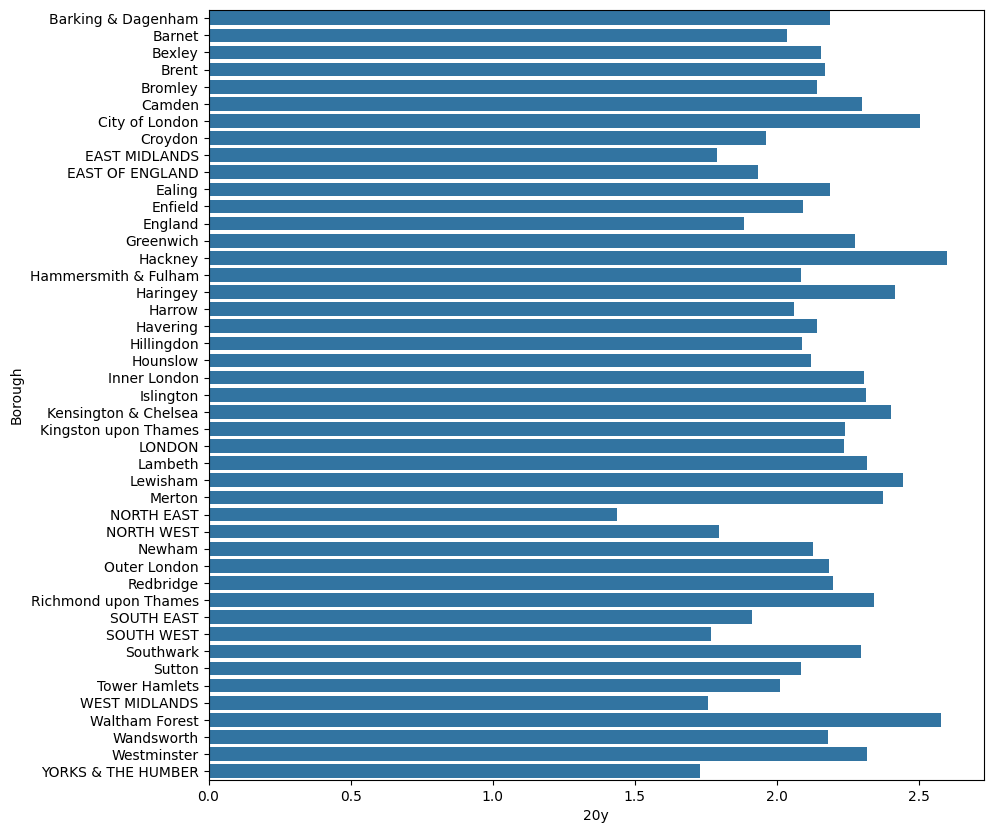

In [101]:
plt.figure(figsize=(10, 10))
sns.barplot(y='Borough', x='20y', data=final)

In [78]:
Top10_20y = final.sort_values(by='20y', ascending= False).head(10)
Top10_20y

,Borough,20y,15y,10y,5y
14,Hackney,2.60,1.97,1.17,1.02
41,Waltham Forest,2.58,2.29,1.42,1.13
6,City of London,2.50,1.72,1.03,0.94
27,Lewisham,2.44,2.07,1.31,1.10
16,Haringey,2.42,1.89,1.24,1.07
23,Kensington & Chelsea,2.40,1.49,0.96,0.95
28,Merton,2.37,1.95,1.28,1.12
34,Richmond upon Thames,2.34,1.80,1.22,1.11
43,Westminster,2.32,1.53,0.96,0.96
26,Lambeth,2.32,1.78,1.12,1.01


In [83]:
Top10_15y = final.sort_values(by='15y', ascending= False).head(10)
Top10_15y

,Borough,20y,15y,10y,5y
23,Kensington & Chelsea,5.08,2.96,1.74,1.21
6,City of London,5.30,2.90,1.84,1.38
43,Westminster,5.35,2.81,1.89,1.29
14,Hackney,6.20,2.71,1.75,1.46
5,Camden,4.93,2.61,1.68,1.26
37,Southwark,5.52,2.53,1.73,1.40
41,Waltham Forest,5.84,2.52,1.89,1.73
26,Lambeth,4.96,2.52,1.73,1.41
16,Haringey,5.13,2.50,1.82,1.48
21,Inner London,5.17,2.50,1.72,1.39


In [84]:
Top10_5y = final.sort_values(by='5y', ascending= False).head(10)
Top10_5y

,Borough,20y,15y,10y,5y
41,Waltham Forest,5.84,2.52,1.89,1.73
0,Barking & Dagenham,4.90,2.07,1.58,1.70
18,Havering,4.33,2.07,1.60,1.64
31,Newham,5.31,2.13,1.62,1.61
2,Bexley,4.25,2.08,1.63,1.61
7,Croydon,4.20,1.99,1.57,1.58
27,Lewisham,5.45,2.41,1.78,1.58
33,Redbridge,4.47,2.08,1.60,1.54
13,Greenwich,4.76,2.27,1.68,1.53
19,Hillingdon,4.20,2.02,1.61,1.52


In [85]:
df_ready.Average_price.max()

1656986.0